## Hand Code

In [1]:
#import library yang dibutuhkan
import pandas as pd

In [2]:
df=pd.read_csv("Masterdataset.csv")
df.head()

,id_nasabah,nama,jenis_kelamin,usia,status_pernikaha,jumlah_tanggunga,pendapatan_per_b,lama_bekerja_tah,jenis_pekerjaan,pendidikan,...,jenis_kredit,tenor_bulan,bunga_per_tahun,cicilan_per_bula,rasio_utang_pend,tanggal_akun_dib,is_default,jumlah_tunggakan,riwayat_tunggaka,skor_kredit_sebe
0,NBS-00001,Wahyu Setiawan,P,26,Belum Menikah,2.0,6193292.0,1.0,Karyawan Swasta,S1,...,KKB,49,6.83,2577223,0.416,2025-05-10,0,4,Pernah 3x atau lebih,593.0
1,NBS-00002,Joko Tanjung,P,31,Cerai,2.0,20491471.0,1.0,Pengusaha,SMA,...,Multiguna,71,8.10,1208811,0.059,2019-01-25,0,0,Tidak Pernah,727.0
2,NBS-00003,Nanda Santoso,P,47,Belum Menikah,2.0,4805010.0,14.0,PNS,SMA,...,Kartu Kredit,15,19.87,964941,0.201,2023-06-30,0,3,Pernah 3x atau lebih,652.0
3,NBS-00004,Sari Valentino,P,47,Menikah,1.0,5389523.0,24.0,Karyawan Swasta,S1,...,KPR,193,17.97,5941643,NaN,2022-07-26,0,1,Pernah 1x,693.0
4,NBS-00005,Joko Kusuma,L,38,Menikah,3.0,4467399.0,11.0,Karyawan Swasta,SMA,...,KPR,217,11.02,4864103,1.089,2021-05-11,0,0,Tidak Pernah,733.0


In [8]:
#melihat shape dataset
df.shape    

(20525, 24)

In [11]:
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Jumlah baris: 20525
Jumlah kolom: 24


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20525 entries, 0 to 20524
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_nasabah        20525 non-null  str    
 1   nama              20525 non-null  str    
 2   jenis_kelamin     20525 non-null  str    
 3   usia              20525 non-null  int64  
 4   status_pernikaha  20525 non-null  str    
 5   jumlah_tanggunga  20095 non-null  float64
 6   pendapatan_per_b  19454 non-null  float64
 7   lama_bekerja_tah  19896 non-null  float64
 8   jenis_pekerjaan   20525 non-null  str    
 9   pendidikan        20525 non-null  str    
 10  kota              20525 non-null  str    
 11  jumlah_kredit_ak  20525 non-null  int64  
 12  total_kredit      19541 non-null  float64
 13  sisa_bayar_kredi  18515 non-null  float64
 14  jenis_kredit      20525 non-null  str    
 15  tenor_bulan       20525 non-null  int64  
 16  bunga_per_tahun   20525 non-null  float64
 17  cici

In [25]:
#Diagnosa Missing Value
missing_values = df.isnull().sum()
# print(missing_values)
missing_value=missing_values[missing_values > 0]

In [15]:
column_names = ["id_nasabah", "nama_nasabah", "jenis_kelamin", "usia", "pekerjaan", "pendapatan_bulanan", "jumlah_tanggungan", "status_pernikahan", "status_rumah", "jumlah_kendaraan", "riwayat_kredit_buruk", "jumlah_transaksi_6bulan_terakhir", "rata_rata_transaksi_6bulan_terakhir", "label"
                ]
print(column_names)

['id_nasabah', 'nama_nasabah', 'jenis_kelamin', 'usia', 'pekerjaan', 'pendapatan_bulanan', 'jumlah_tanggungan', 'status_pernikahan', 'status_rumah', 'jumlah_kendaraan', 'riwayat_kredit_buruk', 'jumlah_transaksi_6bulan_terakhir', 'rata_rata_transaksi_6bulan_terakhir', 'label']


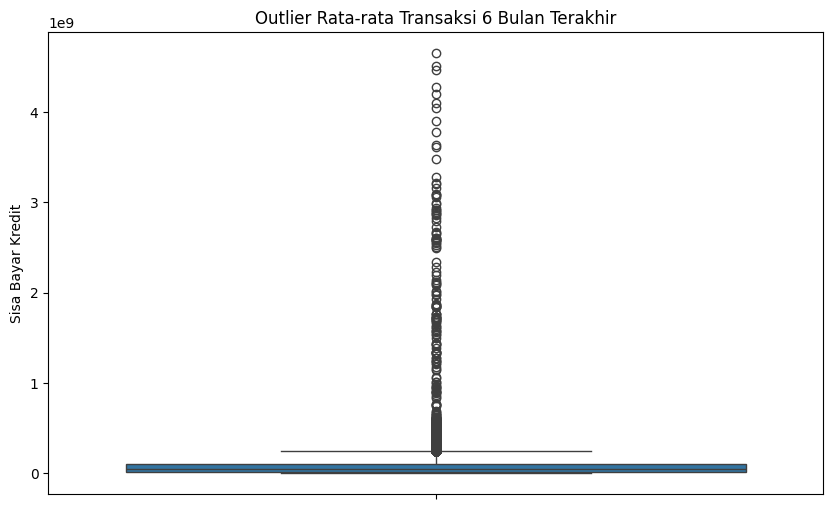

In [23]:
#melihat outlier kolom sisa_bayar_kredi
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['sisa_bayar_kredi'])
plt.title('Outlier Rata-rata Transaksi 6 Bulan Terakhir')
plt.ylabel('Sisa Bayar Kredit')
plt.show()

In [28]:
#menghitung persen missing value dalam bentuk dataframe baru dan sort by persentase missing value
missing_value_percent = (missing_value / len(df)) * 100
missing_value_percent_df = pd.DataFrame({'Kolom': missing_value.index, 'Persentase Missing Value': missing_value_percent.values})
missing_value_percent_df = missing_value_percent_df.sort_values(by='Persentase Missing Value', ascending=False)
print(missing_value_percent_df)

              Kolom  Persentase Missing Value
4  sisa_bayar_kredi                  9.792935
7  skor_kredit_sebe                  8.185140
1  pendapatan_per_b                  5.218027
5  rasio_utang_pend                  5.023143
3      total_kredit                  4.794153
6  riwayat_tunggaka                  3.069428
2  lama_bekerja_tah                  3.064555
0  jumlah_tanggunga                  2.095006


<Axes: >

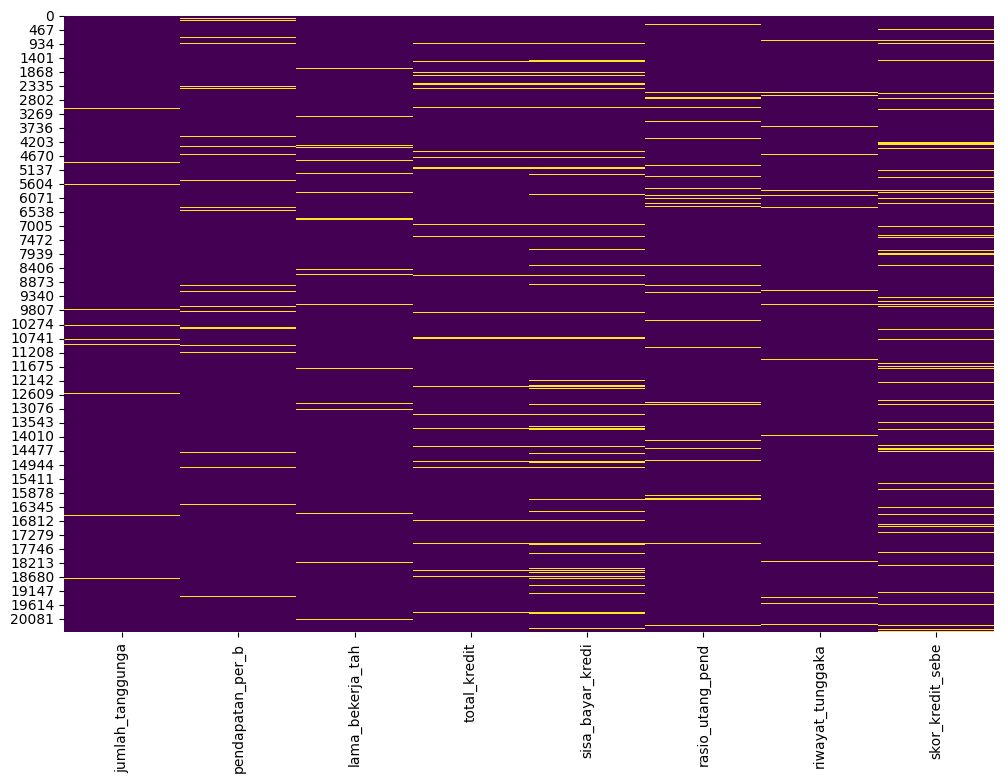

In [30]:
#melakukan visualisasi dengan heatmap menggunakan untuk kolom yang punya missing value
plt.figure(figsize=(12, 8))
sns.heatmap(df[missing_value.index].isnull(), cbar=False, cmap='viridis')

In [34]:
#Mengisi kolom missing value menggunakan mean/median/mode
df_isi = df.copy()
kolom_angka = ["sisa_bayar_kredi", "skor_kredit_sebe"]
for kolom in kolom_angka:
    median_val = df_isi[kolom].median()
    df_isi[kolom].fillna(median_val, inplace=True)

C:\Users\andik\AppData\Local\Temp\ipykernel_21424\2594353863.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_isi[kolom].fillna(median_val, inplace=True)
C:\Users\andik\AppData\Local\Temp\ipykernel_21424\2594353863.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

In [37]:
#melihat missing value setelah diisi
missing_values_setelah_isi = df_isi.isnull().sum()
missing_value_setelah_isi = missing_values_setelah_isi[missing_values_setelah_isi > 0]
print(missing_value_setelah_isi)

jumlah_tanggunga     430
pendapatan_per_b    1071
lama_bekerja_tah     629
total_kredit         984
sisa_bayar_kredi    2010
rasio_utang_pend    1031
riwayat_tunggaka     630
skor_kredit_sebe    1680
dtype: int64


In [41]:
kolom_teks = ["riwayat_tunggakan"]

for kolom in kolom_teks:
    if kolom in df_isi.columns and df_isi[kolom].notna().any():
        mode_val = df_isi[kolom].mode(dropna=True).iloc[0]
        df_isi[kolom] = df_isi[kolom].fillna(mode_val)

In [45]:
#describe
df_isi[missing_cols].describe()

,jumlah_tanggunga,pendapatan_per_b,lama_bekerja_tah,total_kredit,sisa_bayar_kredi,rasio_utang_pend,skor_kredit_sebe
count,20095.000000,1.945400e+04,19896.000000,1.954100e+04,1.851500e+04,19494.000000,18845.000000
mean,2.056233,1.179537e+07,9.828357,2.011389e+08,9.961794e+07,0.679710,663.062775
std,1.565314,6.721248e+07,6.866467,3.682538e+08,2.132786e+08,0.598795,81.336195
min,0.000000,1.500000e+06,0.000000,5.000000e+06,2.645940e+05,0.010000,300.000000
25%,1.000000,4.389274e+06,5.000000,4.619815e+07,1.771224e+07,0.262000,625.000000
50%,2.000000,6.138722e+06,9.000000,9.055341e+07,4.095315e+07,0.477000,677.000000
75%,3.000000,8.209945e+06,14.000000,3.009251e+08,1.067358e+08,0.885000,718.000000
max,7.000000,1.195068e+09,40.000000,4.992338e+09,4.653899e+09,2.500000,850.000000


In [47]:
num_missing_cols = [
    "jumlah_tanggunga",
    "pendapatan_per_b",
    "lama_bekerja_tah",
    "total_kredit",
    "sisa_bayar_kredi",
    "rasio_utang_pend",
    "skor_kredit_sebe"
]

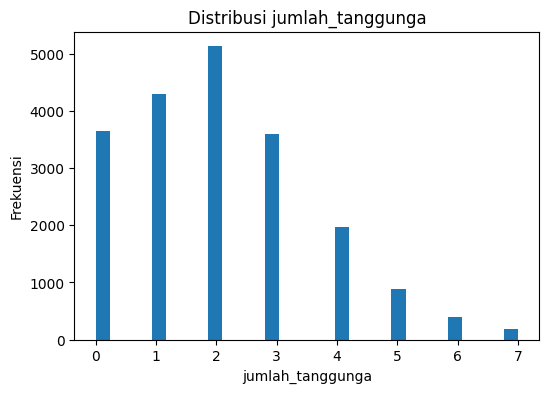

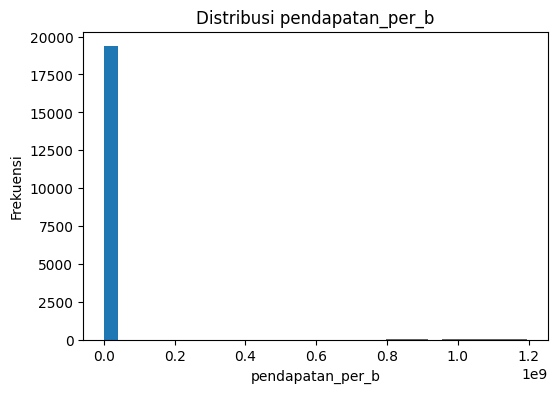

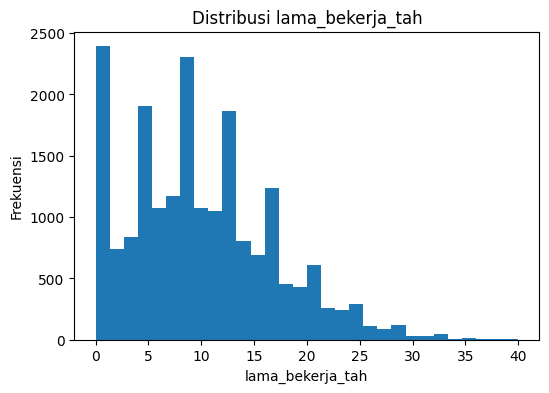

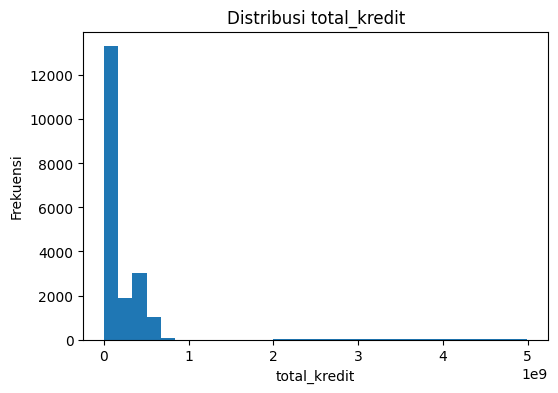

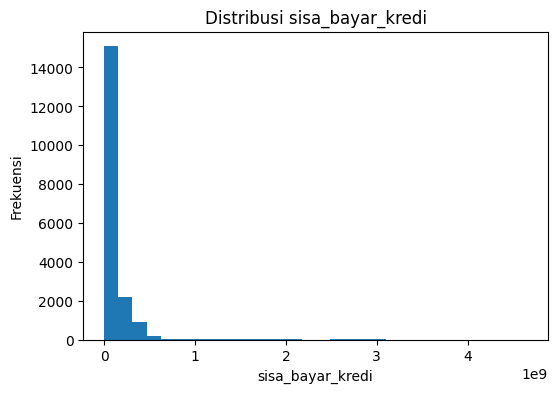

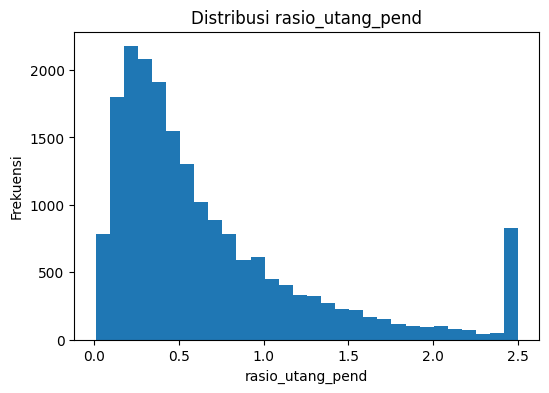

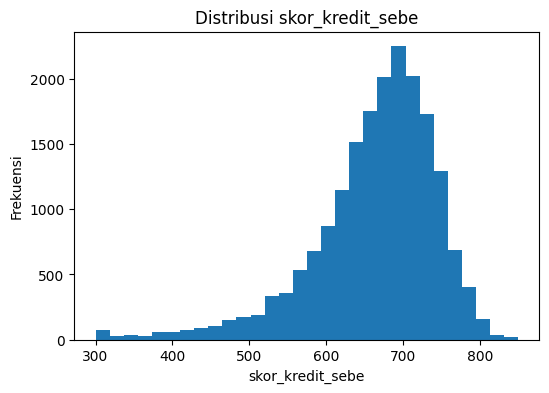

In [48]:
import matplotlib.pyplot as plt

for col in num_missing_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.show()

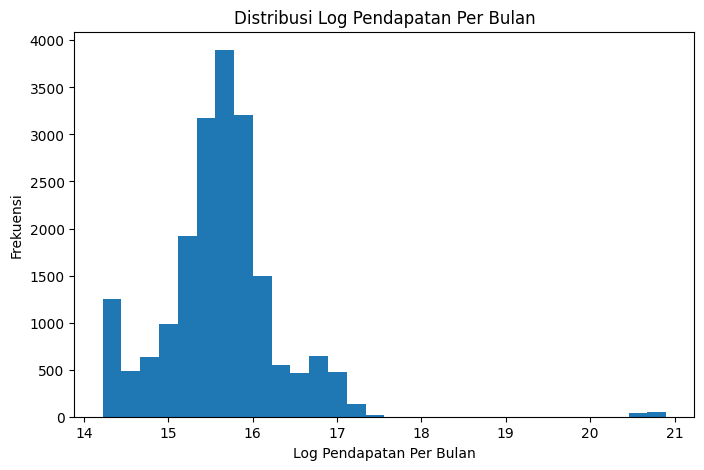

In [56]:
import numpy as np
import matplotlib.pyplot as plt

df["log_pendapatan_per_b"] = np.log1p(df["pendapatan_per_b"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_pendapatan_per_b"].dropna(), bins=30)
plt.title("Distribusi Log Pendapatan Per Bulan")
plt.xlabel("Log Pendapatan Per Bulan")
plt.ylabel("Frekuensi")
plt.show()

| Log Pendapatan | Kira-kira Pendapatan Asli |
| -------------: | ------------------------: |
|             14 |             ± Rp1.200.000 |
|             15 |             ± Rp3.200.000 |
|             16 |             ± Rp8.800.000 |
|             17 |            ± Rp24.000.000 |
|             18 |            ± Rp65.000.000 |
|             20 |           ± Rp485.000.000 |
|             21 |         ± Rp1.300.000.000 |


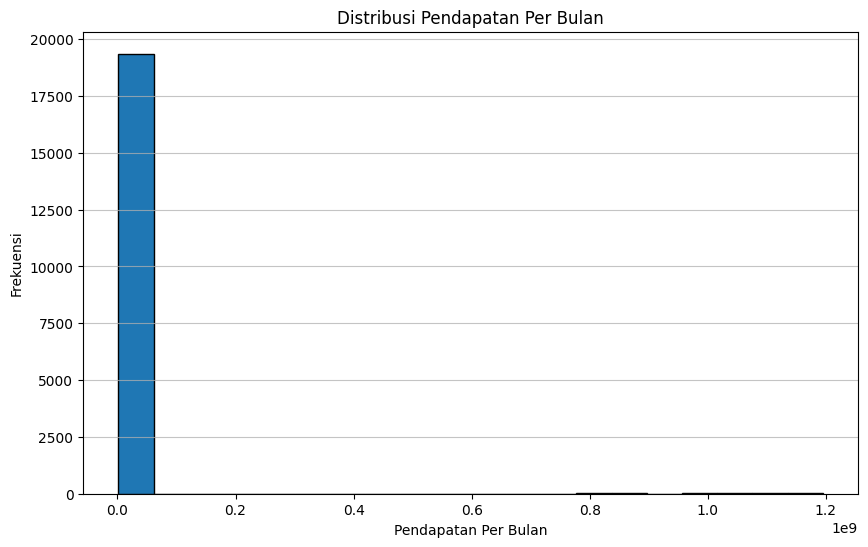

In [54]:
# melihat histogram pendapatan_per_b
plt.figure(figsize=(10, 6))
plt.hist(df['pendapatan_per_b'], bins=20, edgecolor='k')    
plt.title('Distribusi Pendapatan Per Bulan')
plt.xlabel('Pendapatan Per Bulan')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.75)
plt.show()

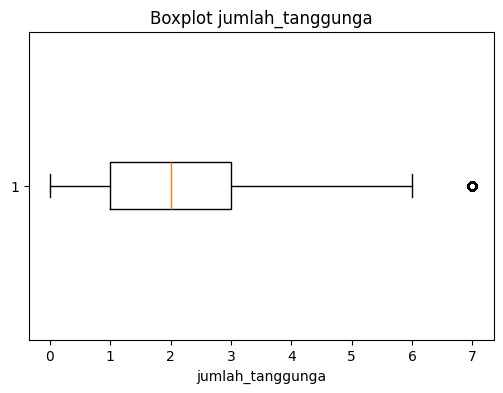

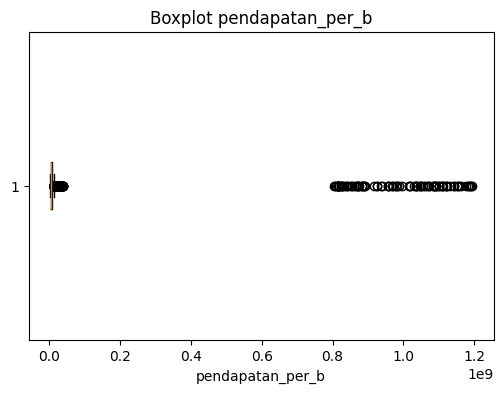

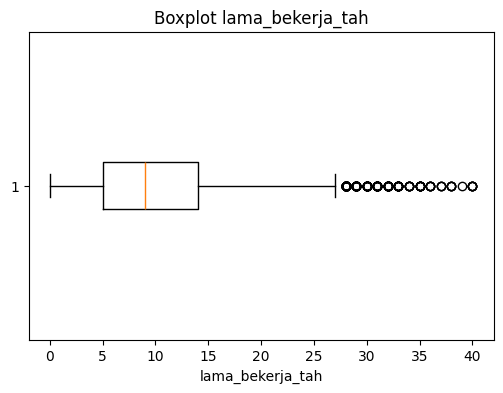

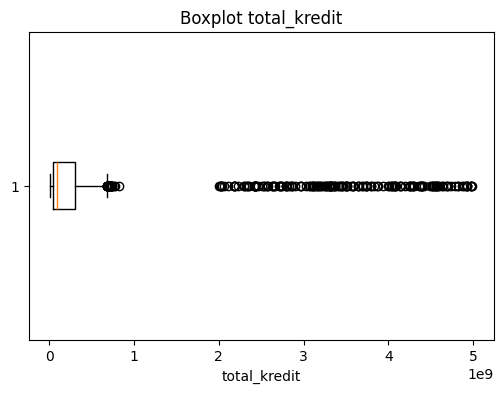

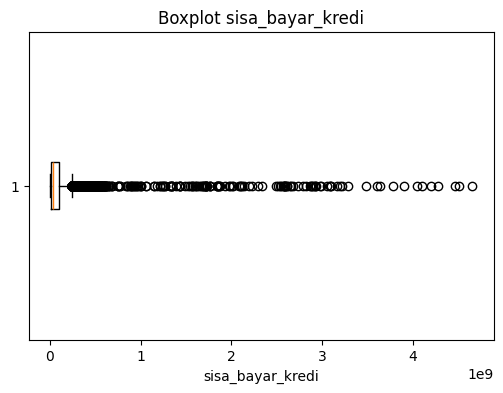

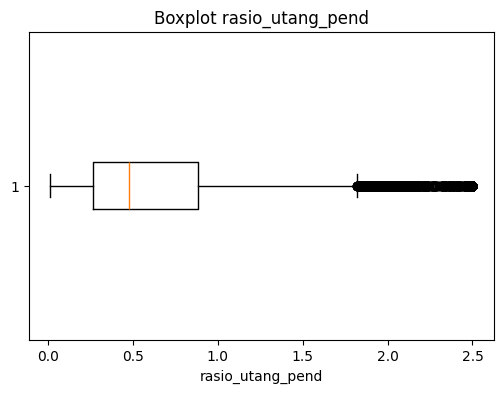

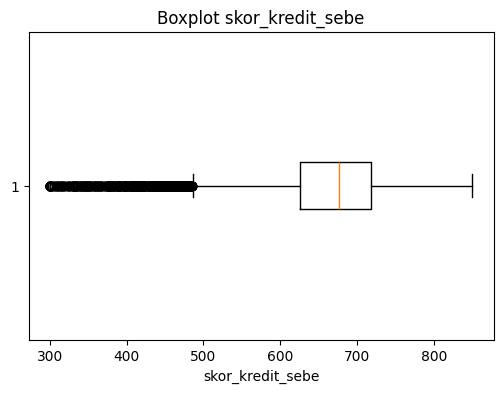

In [49]:
for col in num_missing_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot {col}")
    plt.xlabel(col)
    plt.show()

In [50]:
df[num_missing_cols].skew()

jumlah_tanggunga     0.652282
pendapatan_per_b    14.746557
lama_bekerja_tah     0.640786
total_kredit         7.907746
sisa_bayar_kredi    10.051319
rasio_utang_pend     1.583392
skor_kredit_sebe    -1.282656
dtype: float64

In [51]:
target = "is_default"

for col in missing_cols:
    if target in df.columns:
        print(f"\nDefault rate berdasarkan missing {col}")
        print(df.groupby(df[col].isna())[target].mean())


Default rate berdasarkan missing jumlah_tanggunga
jumlah_tanggunga
False    0.198209
True     0.234884
Name: is_default, dtype: float64

Default rate berdasarkan missing pendapatan_per_b
pendapatan_per_b
False    0.196258
True     0.248366
Name: is_default, dtype: float64

Default rate berdasarkan missing lama_bekerja_tah
lama_bekerja_tah
False    0.200040
True     0.165342
Name: is_default, dtype: float64

Default rate berdasarkan missing total_kredit
total_kredit
False    0.198557
True     0.207317
Name: is_default, dtype: float64

Default rate berdasarkan missing sisa_bayar_kredi
sisa_bayar_kredi
False    0.198488
True     0.203483
Name: is_default, dtype: float64

Default rate berdasarkan missing rasio_utang_pend
rasio_utang_pend
False    0.199856
True     0.182347
Name: is_default, dtype: float64

Default rate berdasarkan missing skor_kredit_sebe
skor_kredit_sebe
False    0.198726
True     0.201786
Name: is_default, dtype: float64


Dari boxplot, mayoritas data pendapatan menumpuk di kiri, sedangkan ada banyak titik jauh di kanan sampai sekitar:1,2 milyar
mean   = Rp11.795.370
median = Rp6.138.722
pendapatan_per_b tidak missing: 19.63%
pendapatan_per_b missing:       24.84%

In [59]:
df.groupby(["jenis_pekerjaan", "pendidikan"])["pendapatan_per_b"].agg(
    count="count",
    median="median"
).sort_values("median", ascending=False)

count      median
jenis_pekerjaan pendidikan                   
Pengusaha       Diploma       366  18130895.5
                SMA           603  18003091.0
                S1           1041  17957258.0
                S2            328  17532692.5
                S3             54  17453673.5
Wiraswasta      S3             69   7019109.0
                SMA          1222   7010102.5
                S1           1793   7007412.0
                Diploma       630   7002596.0
                S2            587   6976025.0
PNS             SMA           912   6053717.0
                S2            463   6050713.0
                Diploma       505   5990029.0
                S1           1502   5942799.0
                S3             88   5795516.5
Karyawan Swasta S2           1088   5596732.0
                S3            155   5570375.0
                SMA          2220   5538987.0
                S1           3517   5476299.0
                Diploma      1202   5396462.5
Tidak Bekerja   S1            454   1519601.0
                S2            127   1512414.0
                SMA           340   1510672.5
                Diploma       165   1500000.0
                S3             23   1500000.0

In [64]:
df[[
    "pendapatan_per_b",
    "total_kredit",
    "sisa_bayar_kredi",
    "cicilan_per_bula",
    "rasio_utang_pend",
    "skor_kredit_sebe",
    "is_default"
]].corr(numeric_only=True)

,pendapatan_per_b,total_kredit,sisa_bayar_kredi,cicilan_per_bula,rasio_utang_pend,skor_kredit_sebe,is_default
pendapatan_per_b,1.000000,0.010716,0.011958,0.005895,-0.109307,-0.010814,-0.056902
total_kredit,0.010716,1.000000,0.845084,0.699996,0.486712,0.011636,0.002596
sisa_bayar_kredi,0.011958,0.845084,1.000000,0.614753,0.415991,0.003317,0.005557
cicilan_per_bula,0.005895,0.699996,0.614753,1.000000,0.290407,0.013878,0.005823
rasio_utang_pend,-0.109307,0.486712,0.415991,0.290407,1.000000,0.000639,0.294684
skor_kredit_sebe,-0.010814,0.011636,0.003317,0.013878,0.000639,1.000000,-0.173827
is_default,-0.056902,0.002596,0.005557,0.005823,0.294684,-0.173827,1.000000


    jenis_pekerjaan pendidikan  count          mean      median           q1  \
2   Karyawan Swasta         S2   1088  1.293534e+07   5596732.0   4262330.50   
3   Karyawan Swasta         S3    155  5.438140e+06   5570375.0   4218597.00   
4   Karyawan Swasta        SMA   2220  9.713608e+06   5538987.0   4201612.25   
1   Karyawan Swasta         S1   3517  9.972624e+06   5476299.0   4138789.00   
0   Karyawan Swasta    Diploma   1202  8.774767e+06   5396462.5   4211402.75   
9               PNS        SMA    912  1.094037e+07   6053717.0   4584936.75   
7               PNS         S2    463  6.112941e+06   6050713.0   4528121.00   
5               PNS    Diploma    505  6.054922e+06   5990029.0   4523193.00   
6               PNS         S1   1502  1.075753e+07   5942799.0   4643048.00   
8               PNS         S3     88  5.738537e+06   5795516.5   4138852.50   
10        Pengusaha    Diploma    366  1.813494e+07  18130895.5  13488305.75   
14        Pengusaha        SMA    603  2

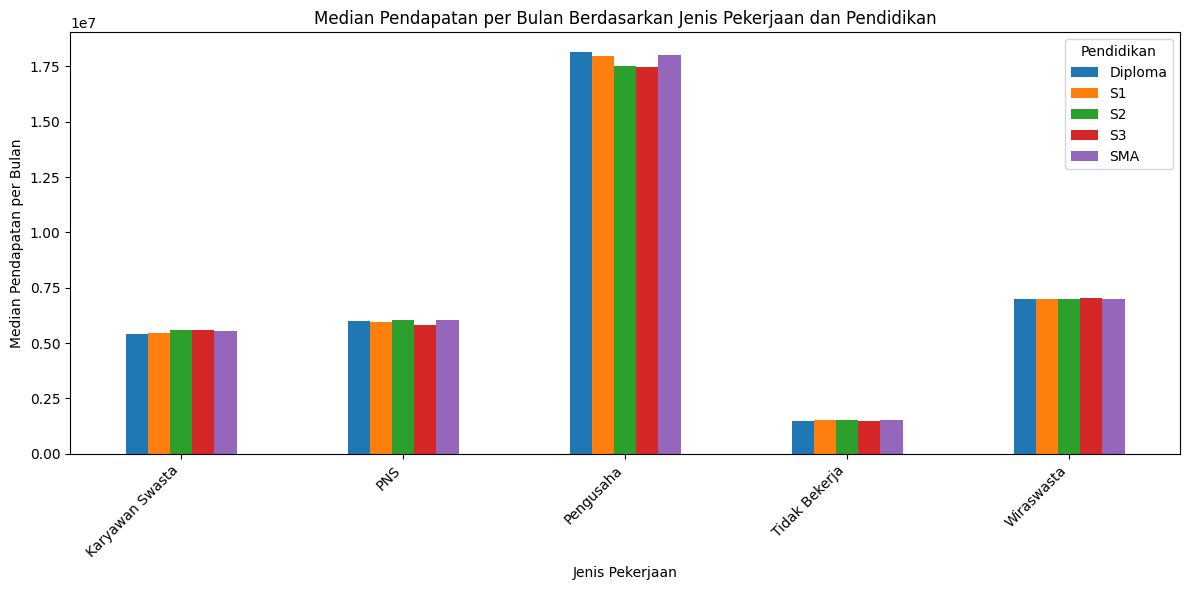

In [73]:
import numpy as np
import matplotlib.pyplot as plt

df["log_pendapatan_per_b"] = np.log1p(df["pendapatan_per_b"])
summary_pendapatan = df.groupby(
    ["jenis_pekerjaan", "pendidikan"]
)["pendapatan_per_b"].agg(
    count="count",
    mean="mean",
    median="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    min="min",
    max="max"
).reset_index()

summary_pendapatan = summary_pendapatan.sort_values(
    ["jenis_pekerjaan", "median"],
    ascending=[True, False]
)

print(summary_pendapatan)
pivot_median = df.pivot_table(
    values="pendapatan_per_b",
    index="jenis_pekerjaan",
    columns="pendidikan",
    aggfunc="median"
)

pivot_median.plot(kind="bar", figsize=(12, 6))

plt.title("Median Pendapatan per Bulan Berdasarkan Jenis Pekerjaan dan Pendidikan")
plt.xlabel("Jenis Pekerjaan")
plt.ylabel("Median Pendapatan per Bulan")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Pendidikan")
plt.tight_layout()
plt.show()

C:\Users\andik\AppData\Local\Temp\ipykernel_21424\4267805791.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_plot, labels=pekerjaan_list, vert=True)


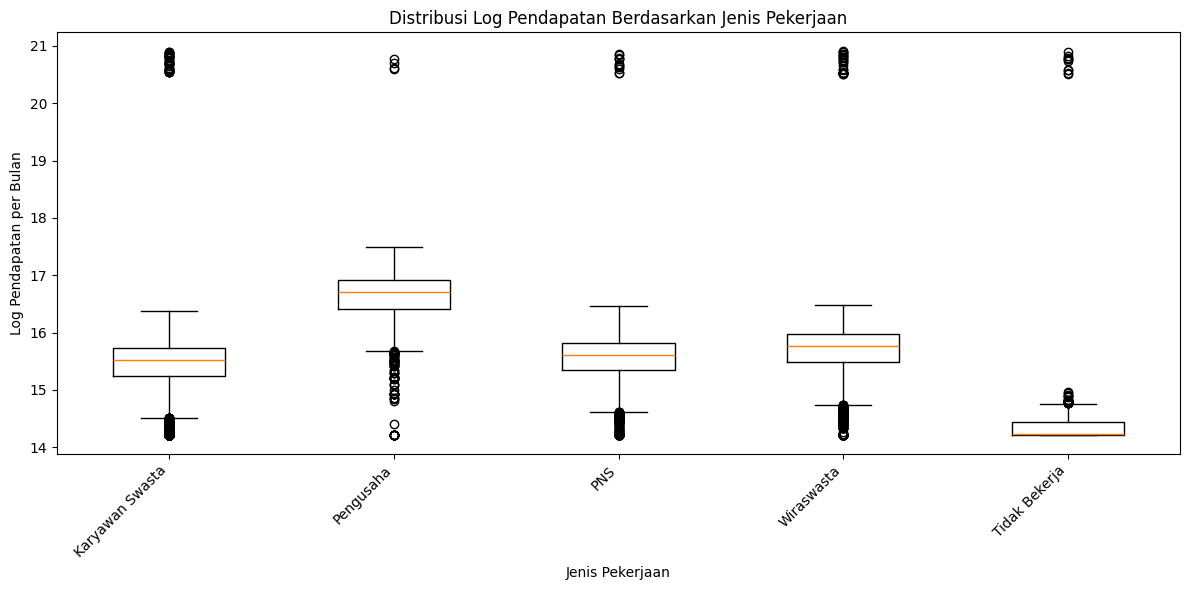

In [74]:
pekerjaan_list = df["jenis_pekerjaan"].dropna().unique()

data_plot = [
    df.loc[df["jenis_pekerjaan"] == pekerjaan, "log_pendapatan_per_b"].dropna()
    for pekerjaan in pekerjaan_list
]

plt.figure(figsize=(12, 6))
plt.boxplot(data_plot, labels=pekerjaan_list, vert=True)

plt.title("Distribusi Log Pendapatan Berdasarkan Jenis Pekerjaan")
plt.xlabel("Jenis Pekerjaan")
plt.ylabel("Log Pendapatan per Bulan")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [72]:
missing_group = df.groupby(
    ["jenis_pekerjaan", "pendidikan"]
)["pendapatan_per_b"].apply(
    lambda x: x.isna().mean() * 100
).reset_index(name="missing_percent")

missing_group = missing_group.sort_values("missing_percent", ascending=False)

print(missing_group)

    jenis_pekerjaan pendidikan  missing_percent
8               PNS         S3         9.278351
17    Tidak Bekerja         S2         7.299270
4   Karyawan Swasta        SMA         6.801008
23       Wiraswasta         S3         6.756757
11        Pengusaha         S1         6.469003
12        Pengusaha         S2         6.285714
0   Karyawan Swasta    Diploma         5.946792
14        Pengusaha        SMA         5.928237
21       Wiraswasta         S1         5.829832
16    Tidak Bekerja         S1         5.809129
6               PNS         S1         5.653266
19    Tidak Bekerja        SMA         5.027933
2   Karyawan Swasta         S2         4.978166
20       Wiraswasta    Diploma         4.833837
10        Pengusaha    Diploma         4.687500
5               PNS    Diploma         4.536862
24       Wiraswasta        SMA         4.231975
1   Karyawan Swasta         S1         4.168937
9               PNS        SMA         4.100946
22       Wiraswasta         S2         4

C:\Users\andik\AppData\Local\Temp\ipykernel_21424\3579004046.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_plot, labels=pendidikan_list, vert=True)


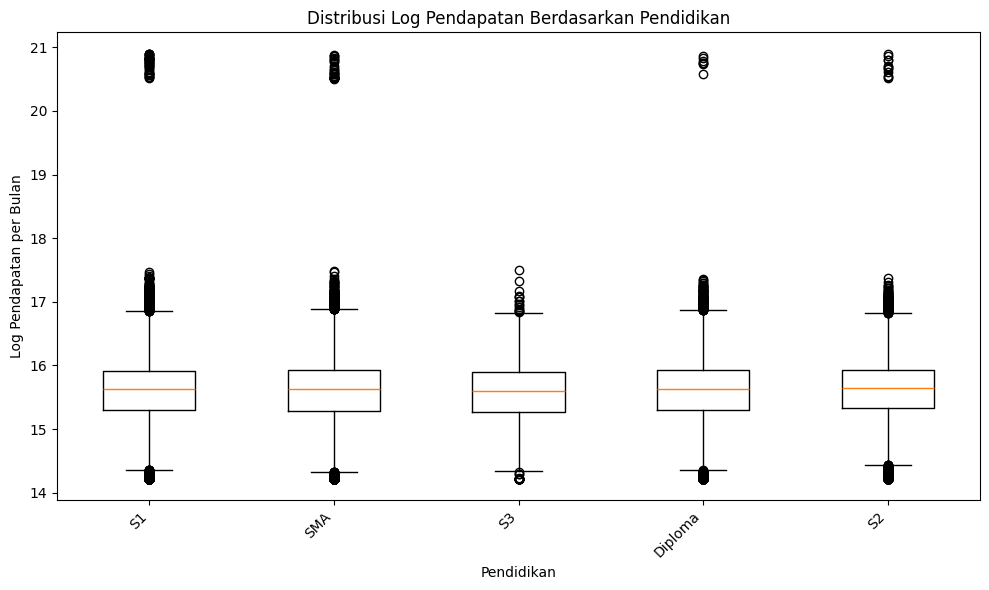

In [75]:
pendidikan_list = df["pendidikan"].dropna().unique()

data_plot = [
    df.loc[df["pendidikan"] == pendidikan, "log_pendapatan_per_b"].dropna()
    for pendidikan in pendidikan_list
]

plt.figure(figsize=(10, 6))
plt.boxplot(data_plot, labels=pendidikan_list, vert=True)

plt.title("Distribusi Log Pendapatan Berdasarkan Pendidikan")
plt.xlabel("Pendidikan")
plt.ylabel("Log Pendapatan per Bulan")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [65]:
df["pendapatan_per_b_missing"] = df["pendapatan_per_b"].isna().astype(int)

df["pendapatan_per_b"] = df.groupby(
    ["jenis_pekerjaan", "pendidikan"]
)["pendapatan_per_b"].transform(lambda x: x.fillna(x.median()))

df["pendapatan_per_b"] = df.groupby(
    "jenis_pekerjaan"
)["pendapatan_per_b"].transform(lambda x: x.fillna(x.median()))

df["pendapatan_per_b"] = df["pendapatan_per_b"].fillna(
    df["pendapatan_per_b"].median()
)

In [66]:
df["pendapatan_per_b"].isna().sum()

np.int64(0)

## Vibe-Code

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20525 entries, 0 to 20524
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_nasabah        20525 non-null  str    
 1   nama              20525 non-null  str    
 2   jenis_kelamin     20525 non-null  str    
 3   usia              20525 non-null  int64  
 4   status_pernikaha  20525 non-null  str    
 5   jumlah_tanggunga  20095 non-null  float64
 6   pendapatan_per_b  19454 non-null  float64
 7   lama_bekerja_tah  19896 non-null  float64
 8   jenis_pekerjaan   20525 non-null  str    
 9   pendidikan        20525 non-null  str    
 10  kota              20525 non-null  str    
 11  jumlah_kredit_ak  20525 non-null  int64  
 12  total_kredit      19541 non-null  float64
 13  sisa_bayar_kredi  20525 non-null  float64
 14  jenis_kredit      20525 non-null  str    
 15  tenor_bulan       20525 non-null  int64  
 16  bunga_per_tahun   20525 non-null  float64
 17  cici

In [5]:
# Melihat missing value masing masing kolom dan persentasenya
missing_values = df.isnull().sum()
missing_value = missing_values[missing_values > 0]
missing_percentage = (missing_value / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_value,
    "missing_percentage": missing_percentage,
})

print(missing_summary)


                  missing_count  missing_percentage
jumlah_tanggunga            430                2.10
pendapatan_per_b           1071                5.22
lama_bekerja_tah            629                3.06
total_kredit                984                4.79
sisa_bayar_kredi           2010                9.79
rasio_utang_pend           1031                5.02
riwayat_tunggaka            630                3.07
skor_kredit_sebe           1680                8.19


### Proses Data Cleaning untuk Mendeteksi dan Mengisi Missing Value

In [7]:
# Mengisi missing value pada kolom sisa bayar kredit dengan median
median_sisa_bayar_kredit = df["sisa_bayar_kredi"].median()
df["sisa_bayar_kredi"] = df["sisa_bayar_kredi"].fillna(median_sisa_bayar_kredit)

print("Median sisa_bayar_kredi:", median_sisa_bayar_kredit)
print("Sisa missing value:", df["sisa_bayar_kredi"].isna().sum())

Median sisa_bayar_kredi: 40953147.0
Sisa missing value: 0


In [16]:
# Mengisi missing value sisa_bayar_kredi dengan rata-rata bertingkat berdasarkan pekerjaan, rasio utang, dan status default
kolom_target = "sisa_bayar_kredi"

# Buat bucket rasio utang pendapatan agar pengelompokan numerik lebih stabil
rasio_bucket = pd.qcut(df["rasio_utang_pend"], q=5, duplicates="drop")

# Imputasi utama: rata-rata per kombinasi pekerjaan, bucket rasio utang, dan is_default
group_mean = df.groupby(["jenis_pekerjaan", rasio_bucket, "is_default"])[kolom_target].transform("mean")
df[kolom_target] = df[kolom_target].fillna(group_mean)

# Fallback bila masih ada missing value
if df[kolom_target].isna().any():
    group_mean_pekerjaan_default = df.groupby(["jenis_pekerjaan", "is_default"])[kolom_target].transform("mean")
    df[kolom_target] = df[kolom_target].fillna(group_mean_pekerjaan_default)

if df[kolom_target].isna().any():
    df[kolom_target] = df[kolom_target].fillna(df[kolom_target].median())

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print("Contoh median keseluruhan:", df[kolom_target].median())
#print skor kredit sebelumnya berdasar pekerjaan, rasio utang, dan status default
group_skor = df.groupby(["jenis_pekerjaan", rasio_bucket, "is_default"])["skor_kredit_sebe"].mean().reset_index()
print(group_skor)


Sisa missing value setelah imputasi: 0
Contoh median keseluruhan: 40953147.0
    jenis_pekerjaan               rasio_utang_pend  is_default  \
0   Karyawan Swasta  (0.009000000000000001, 0.227]           0   
1   Karyawan Swasta  (0.009000000000000001, 0.227]           1   
2   Karyawan Swasta                 (0.227, 0.381]           0   
3   Karyawan Swasta                 (0.227, 0.381]           1   
4   Karyawan Swasta                 (0.381, 0.599]           0   
5   Karyawan Swasta                 (0.381, 0.599]           1   
6   Karyawan Swasta                 (0.599, 1.026]           0   
7   Karyawan Swasta                 (0.599, 1.026]           1   
8   Karyawan Swasta                   (1.026, 2.5]           0   
9   Karyawan Swasta                   (1.026, 2.5]           1   
10              PNS  (0.009000000000000001, 0.227]           0   
11              PNS  (0.009000000000000001, 0.227]           1   
12              PNS                 (0.227, 0.381]           0   

In [15]:
# Mengisi missing value pada pendapatan_per_b berdasarkan jenis pekerjaan dan total kredit
kolom_target = "pendapatan_per_b"

# Rata-rata per kelompok pekerjaan dan total kredit
group_mean = df.groupby(["jenis_pekerjaan", "total_kredit"])[kolom_target].transform("mean")
df[kolom_target] = df[kolom_target].fillna(group_mean)

# Fallback jika masih ada missing value
if df[kolom_target].isna().any():
    job_mean = df.groupby("jenis_pekerjaan")[kolom_target].transform("mean")
    df[kolom_target] = df[kolom_target].fillna(job_mean)

if df[kolom_target].isna().any():
    df[kolom_target] = df[kolom_target].fillna(df[kolom_target].median())

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df.groupby(["jenis_pekerjaan", "total_kredit"])[kolom_target].mean().head())


Sisa missing value setelah imputasi: 0
jenis_pekerjaan  total_kredit
Karyawan Swasta  5000000.0       6.052852e+06
                 5538785.0       7.893009e+06
                 5628375.0       1.500000e+06
                 5818233.0       5.512216e+06
                 6161789.0       9.754422e+06
Name: pendapatan_per_b, dtype: float64


In [17]:
# Mengisi missing value pada rasio_utang_pend dengan perhitungan per nasabah
kolom_target = "rasio_utang_pend"

rasio_hitung = df["cicilan_per_bula"] / df["pendapatan_per_b"]
df[kolom_target] = df[kolom_target].fillna(rasio_hitung)

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df[["cicilan_per_bula", "pendapatan_per_b", kolom_target]].head())


Sisa missing value setelah imputasi: 0
   cicilan_per_bula  pendapatan_per_b  rasio_utang_pend
0           2577223         6193292.0          0.416000
1           1208811        20491471.0          0.059000
2            964941         4805010.0          0.201000
3           5941643         5389523.0          1.102443
4           4864103         4467399.0          1.089000


In [19]:
# Mengisi missing value pada total_kredit dengan tenor_bulan dikali cicilan_per_bula
kolom_target = "total_kredit"

total_kredit_hitung = df["tenor_bulan"] * df["cicilan_per_bula"]
df[kolom_target] = df[kolom_target].fillna(total_kredit_hitung)

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df[["tenor_bulan", "cicilan_per_bula", kolom_target]].head())

Sisa missing value setelah imputasi: 0
   tenor_bulan  cicilan_per_bula  total_kredit
0           49           2577223   109932189.0
1           71           1208811    68007609.0
2           15            964941    12724081.0
3          193           5941643   374246142.0
4          217           4864103   456805049.0


In [21]:
# Mengisi missing value pada riwayat_tunggaka berdasarkan jumlah_tunggakan
kolom_target = "riwayat_tunggaka"

# Isi dengan kategori yang paling sering muncul pada setiap jumlah_tunggakan
group_mode = df.groupby("jumlah_tunggakan")[kolom_target].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA
)
df[kolom_target] = df[kolom_target].fillna(group_mode)

# Fallback ke mode global jika masih ada missing value
if df[kolom_target].isna().any():
    df[kolom_target] = df[kolom_target].fillna(df[kolom_target].mode().iloc[0])

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df[["jumlah_tunggakan", kolom_target]].head())


Sisa missing value setelah imputasi: 0
   jumlah_tunggakan      riwayat_tunggaka
0                 4  Pernah 3x atau lebih
1                 0          Tidak Pernah
2                 3  Pernah 3x atau lebih
3                 1             Pernah 1x
4                 0          Tidak Pernah


In [24]:
# Mengisi missing value pada lama_bekerja_tah berdasarkan rentang usia dan rentang pendapatan di tiap rentang usia
kolom_target = "lama_bekerja_tah"

# Buat rentang usia
usia_bins = [17, 25, 35, 45, 55, 65, 100]
usia_label = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df["usia_range"] = pd.cut(df["usia"], bins=usia_bins, labels=usia_label, include_lowest=True)

# Buat rentang pendapatan di dalam setiap rentang usia
pendapatan_range = pd.Series(index=df.index, dtype="object")
for label in usia_label:
    mask = df["usia_range"] == label
    if mask.any():
        try:
            pendapatan_range.loc[mask] = pd.qcut(
                df.loc[mask, "pendapatan_per_b"],
                q=4,
                duplicates="drop"
            ).astype(str)
        except Exception:
            pendapatan_range.loc[mask] = "all"

df["pendapatan_range_usia"] = pendapatan_range

# Median lama bekerja berdasarkan kombinasi rentang usia dan rentang pendapatan
group_median = df.groupby(["usia_range", "pendapatan_range_usia"])[kolom_target].transform("median")
df[kolom_target] = df[kolom_target].fillna(group_median)

# Fallback bertahap bila masih ada missing value
if df[kolom_target].isna().any():
    age_median = df.groupby("usia_range")[kolom_target].transform("median")
    df[kolom_target] = df[kolom_target].fillna(age_median)

if df[kolom_target].isna().any():
    df[kolom_target] = df[kolom_target].fillna(df[kolom_target].median())

# Rapikan kolom bantu jika tidak ingin dipakai lagi
df.drop(columns=["usia_range", "pendapatan_range_usia"], inplace=True)

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df[["usia", "pendapatan_per_b", kolom_target]].head())


Sisa missing value setelah imputasi: 0
   usia  pendapatan_per_b  lama_bekerja_tah
0    26         6193292.0               1.0
1    31        20491471.0               1.0
2    47         4805010.0              14.0
3    47         5389523.0              24.0
4    38         4467399.0              11.0


In [25]:
# Mengisi missing value pada jumlah_tanggunga berdasarkan rentang usia dan rentang pendapatan di tiap rentang usia
kolom_target = "jumlah_tanggunga"

# Buat rentang usia
usia_bins = [17, 25, 35, 45, 55, 65, 100]
usia_label = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df["usia_range"] = pd.cut(df["usia"], bins=usia_bins, labels=usia_label, include_lowest=True)

# Buat rentang pendapatan pada tiap rentang usia
pendapatan_range_usia = pd.Series(index=df.index, dtype="object")
for label_usia in usia_label:
    mask = df["usia_range"] == label_usia
    if mask.any():
        try:
            pendapatan_range_usia.loc[mask] = pd.qcut(
                df.loc[mask, "pendapatan_per_b"],
                q=4,
                duplicates="drop"
            ).astype(str)
        except Exception:
            pendapatan_range_usia.loc[mask] = "all"

df["pendapatan_range_usia"] = pendapatan_range_usia

# Median jumlah tanggungan berdasarkan kombinasi rentang usia dan rentang pendapatan
group_median = df.groupby(["usia_range", "pendapatan_range_usia"])[kolom_target].transform("median")
df[kolom_target] = df[kolom_target].fillna(group_median)

# Fallback bertahap bila masih ada missing value
if df[kolom_target].isna().any():
    age_median = df.groupby("usia_range")[kolom_target].transform("median")
    df[kolom_target] = df[kolom_target].fillna(age_median)

if df[kolom_target].isna().any():
    df[kolom_target] = df[kolom_target].fillna(df[kolom_target].median())

# Hapus kolom bantu
df.drop(columns=["usia_range", "pendapatan_range_usia"], inplace=True)

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df[["usia", "pendapatan_per_b", kolom_target]].head())


Sisa missing value setelah imputasi: 0
   usia  pendapatan_per_b  jumlah_tanggunga
0    26         6193292.0               2.0
1    31        20491471.0               2.0
2    47         4805010.0               2.0
3    47         5389523.0               1.0
4    38         4467399.0               3.0


In [27]:
# Mengisi missing value pada skor_kredit_sebe dengan mempertimbangkan beberapa variabel
kolom_target = "skor_kredit_sebe"

# Bucket rasio utang dan pendapatan agar grouping lebih stabil
rasio_bucket = pd.qcut(df["rasio_utang_pend"], q=5, duplicates="drop")
pendapatan_bucket = pd.qcut(df["pendapatan_per_b"], q=5, duplicates="drop")

# Imputasi utama: median per kombinasi variabel
group_median = df.groupby(["jenis_pekerjaan", "pendidikan", rasio_bucket, pendapatan_bucket, "is_default"])[kolom_target].transform("median")
df[kolom_target] = df[kolom_target].fillna(group_median)

# Fallback bertahap jika masih ada missing value
if df[kolom_target].isna().any():
    fallback_1 = df.groupby(["jenis_pekerjaan", rasio_bucket, "is_default"])[kolom_target].transform("median")
    df[kolom_target] = df[kolom_target].fillna(fallback_1)

if df[kolom_target].isna().any():
    fallback_2 = df.groupby(["jenis_pekerjaan", "is_default"])[kolom_target].transform("median")
    df[kolom_target] = df[kolom_target].fillna(fallback_2)

if df[kolom_target].isna().any():
    df[kolom_target] = df[kolom_target].fillna(df[kolom_target].median())

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df[["jenis_pekerjaan", "pendidikan", "rasio_utang_pend", "pendapatan_per_b", "is_default", kolom_target]].head())


Sisa missing value setelah imputasi: 0
   jenis_pekerjaan pendidikan  rasio_utang_pend  pendapatan_per_b  is_default  \
0  Karyawan Swasta         S1          0.416000         6193292.0           0   
1        Pengusaha        SMA          0.059000        20491471.0           0   
2              PNS        SMA          0.201000         4805010.0           0   
3  Karyawan Swasta         S1          1.102443         5389523.0           0   
4  Karyawan Swasta        SMA          1.089000         4467399.0           0   

   skor_kredit_sebe  
0             593.0  
1             727.0  
2             652.0  
3             693.0  
4             733.0  


### Memeriksa dataframe sekarang

In [29]:
# cek missing value setelah semua imputasi
missing_values_final = df.isnull().sum()
missing_value_final = missing_values_final[missing_values_final > 0]
#cek data duplikat dan tampilkan contohnya
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")
if duplicate_count > 0:
    print("Contoh data duplikat:")
    print(df[df.duplicated(keep=False)])    

Jumlah data duplikat: 525
Contoh data duplikat:
      id_nasabah             nama jenis_kelamin  usia status_pernikaha  \
9      NBS-00010   Putri Maharani             P    25            Cerai   
10     NBS-00010   Putri Maharani             P    25            Cerai   
11     NBS-00010   Putri Maharani             P    25            Cerai   
12     NBS-00010   Putri Maharani             P    25            Cerai   
140    NBS-00138     Yudi Pratama             L    54    Belum Menikah   
...          ...              ...           ...   ...              ...   
20520  NBS-02229  Cahyo Kurniawan             L    39    Belum Menikah   
20521  NBS-18751     Umar Suharto             L    36          Menikah   
20522  NBS-18751     Umar Suharto             L    36          Menikah   
20523  NBS-18751     Umar Suharto             L    36          Menikah   
20524  NBS-18751     Umar Suharto             L    36          Menikah   

       jumlah_tanggunga  pendapatan_per_b  lama_bekerja_tah  je

In [30]:
#hapus data duplikat yg isi semua kolomnya sama
df = df.drop_duplicates()
print(f"Jumlah data setelah menghapus duplikat: {len(df)}")
#perbandingkan jumlah data sebelum dan sesudah menghapus duplikat
print(f"Jumlah data sebelum menghapus duplikat: {len(df) + duplicate_count}")

Jumlah data setelah menghapus duplikat: 20000
Jumlah data sebelum menghapus duplikat: 20525


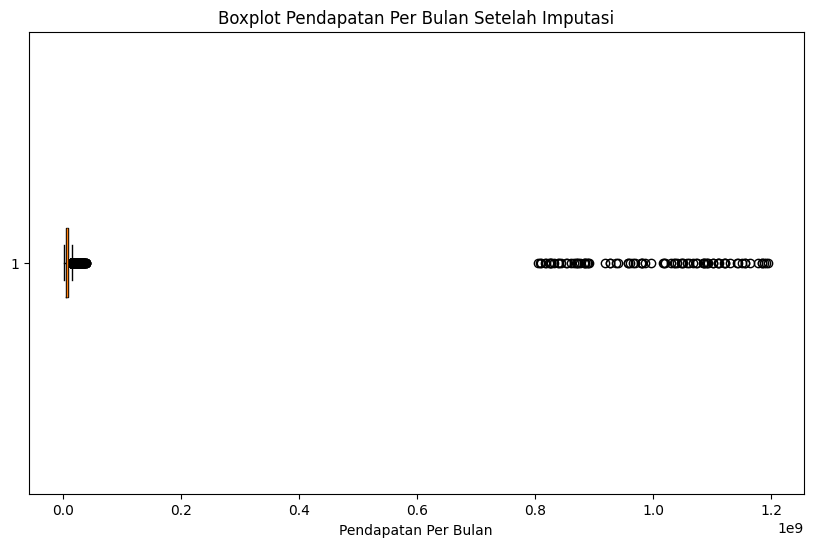

In [31]:
#boxplot kolom pendapatan_per_b setelah imputasi
plt.figure(figsize=(10, 6))
plt.boxplot(df['pendapatan_per_b'], vert=False)
plt.title('Boxplot Pendapatan Per Bulan Setelah Imputasi')
plt.xlabel('Pendapatan Per Bulan')
plt.show()

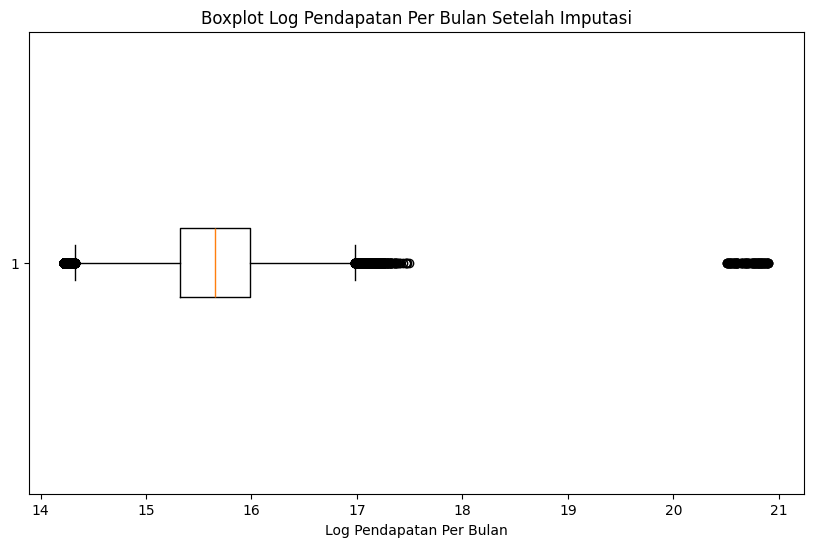

In [35]:
import numpy as np
#buat transformasilog pendapatan per b dan buat boxplotnya
df["log_pendapatan_per_b"] = np.log1p(df["pendapatan_per_b"])
plt.figure(figsize=(10, 6))
plt.boxplot(df['log_pendapatan_per_b'], vert=False)
plt.title('Boxplot Log Pendapatan Per Bulan Setelah Imputasi')
plt.xlabel('Log Pendapatan Per Bulan')
plt.show()

In [36]:
#cek skewneness pendapatan_per_b setelah ditransformasi log
skewness_log = df["log_pendapatan_per_b"].skew()
print(f"Skewness Log Pendapatan Per Bulan: {skewness_log}")

Skewness Log Pendapatan Per Bulan: 1.3843058524568594


In [37]:
batas = df["log_pendapatan_per_b"].quantile(0.99)

df[df["log_pendapatan_per_b"] >= batas][
    [
        "id_nasabah",
        "jenis_pekerjaan",
        "pendidikan",
        "pendapatan_per_b",
        "log_pendapatan_per_b",
        "total_kredit",
        "is_default"
    ]
].sort_values("pendapatan_per_b", ascending=False)

,id_nasabah,jenis_pekerjaan,pendidikan,pendapatan_per_b,log_pendapatan_per_b,total_kredit,is_default
18126,NBS-17938,Wiraswasta,S1,1.195068e+09,20.901469,4.359694e+09,0
13337,NBS-13203,Tidak Bekerja,S1,1.191645e+09,20.898601,1.690462e+08,0
15997,NBS-15839,Wiraswasta,S1,1.187109e+09,20.894786,2.606016e+07,0
875,NBS-00861,Wiraswasta,S1,1.184492e+09,20.892580,3.457302e+07,0
15379,NBS-15221,Karyawan Swasta,S2,1.183638e+09,20.891859,4.510634e+07,0
...,...,...,...,...,...,...,...
19628,NBS-19416,Pengusaha,S1,2.836688e+07,17.160733,4.024931e+08,0
2832,NBS-02791,Pengusaha,S2,2.834851e+07,17.160085,7.897492e+07,0
11075,NBS-10968,Pengusaha,S1,2.829885e+07,17.158332,2.288658e+07,0
20186,NBS-19962,Pengusaha,Diploma,2.827436e+07,17.157466,1.281252e+08,0


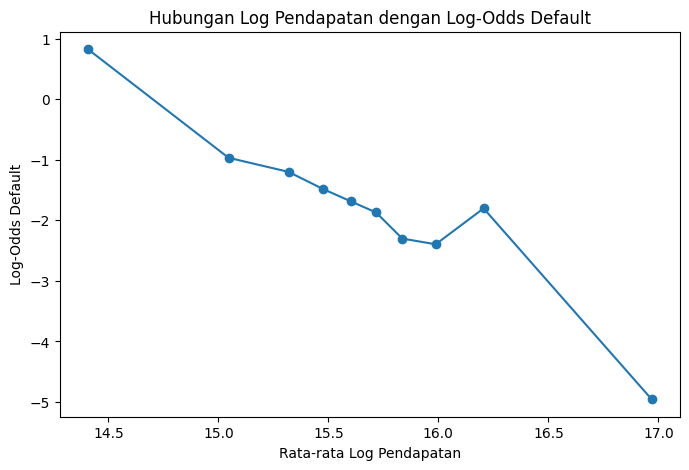

             bucket  rata_log_pendapatan  default_rate  jumlah_data  \
0   (14.22, 14.794]            14.407469        0.6955         2000   
1  (14.794, 15.218]            15.046272        0.2755         2000   
2  (15.218, 15.408]            15.319220        0.2315         2000   
3  (15.408, 15.542]            15.477704        0.1845         2000   
4  (15.542, 15.659]            15.600928        0.1565         2000   
5  (15.659, 15.775]            15.716903        0.1335         2000   
6  (15.775, 15.904]            15.835982        0.0910         2000   
7  (15.904, 16.077]            15.987928        0.0835         2000   
8  (16.077, 16.411]            16.205629        0.1415         2000   
9  (16.411, 20.901]            16.969084        0.0070         2000   

   default_rate_aman  logit_default  
0             0.6955       0.825960  
1             0.2755      -0.966894  
2             0.2315      -1.199861  
3             0.1845      -1.486152  
4             0.1565      -1

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cek_logit = df[
    ["log_pendapatan_per_b", "is_default"]
].dropna().copy()

cek_logit["bucket"] = pd.qcut(
    cek_logit["log_pendapatan_per_b"],
    q=10,
    duplicates="drop"
)

ringkasan = cek_logit.groupby(
    "bucket",
    observed=True
).agg(
    rata_log_pendapatan=("log_pendapatan_per_b", "mean"),
    default_rate=("is_default", "mean"),
    jumlah_data=("is_default", "size")
).reset_index()

epsilon = 1e-6

ringkasan["default_rate_aman"] = ringkasan[
    "default_rate"
].clip(epsilon, 1 - epsilon)

ringkasan["logit_default"] = np.log(
    ringkasan["default_rate_aman"] /
    (1 - ringkasan["default_rate_aman"])
)

plt.figure(figsize=(8, 5))
plt.scatter(
    ringkasan["rata_log_pendapatan"],
    ringkasan["logit_default"]
)
plt.plot(
    ringkasan["rata_log_pendapatan"],
    ringkasan["logit_default"]
)
plt.xlabel("Rata-rata Log Pendapatan")
plt.ylabel("Log-Odds Default")
plt.title("Hubungan Log Pendapatan dengan Log-Odds Default")
plt.show()

print(ringkasan)

In [42]:
p99 = df["pendapatan_per_b"].quantile(0.99)

data_ekstrem = df[
    df["pendapatan_per_b"] > p99
].copy()

ringkasan_ekstrem = data_ekstrem.groupby(
    "jenis_pekerjaan"
).agg(
    jumlah_nasabah=("id_nasabah", "count"),
    pendapatan_min=("pendapatan_per_b", "min"),
    pendapatan_median=("pendapatan_per_b", "median"),
    pendapatan_max=("pendapatan_per_b", "max"),
    default_rate=("is_default", "mean")
).sort_values("jumlah_nasabah", ascending=False)

print(ringkasan_ekstrem)

                 jumlah_nasabah  pendapatan_min  pendapatan_median  \
jenis_pekerjaan                                                      
Pengusaha                   120      28262825.0       3.021871e+07   
Karyawan Swasta              37     831127088.0       1.016024e+09   
Wiraswasta                   21     805019157.0       1.029830e+09   
PNS                          12     826998108.0       9.469419e+08   
Tidak Bekerja                10     809656049.0       1.033890e+09   

                 pendapatan_max  default_rate  
jenis_pekerjaan                                
Pengusaha          1.039619e+09           0.0  
Karyawan Swasta    1.183638e+09           0.0  
Wiraswasta         1.195068e+09           0.0  
PNS                1.142251e+09           0.0  
Tidak Bekerja      1.191645e+09           0.0  


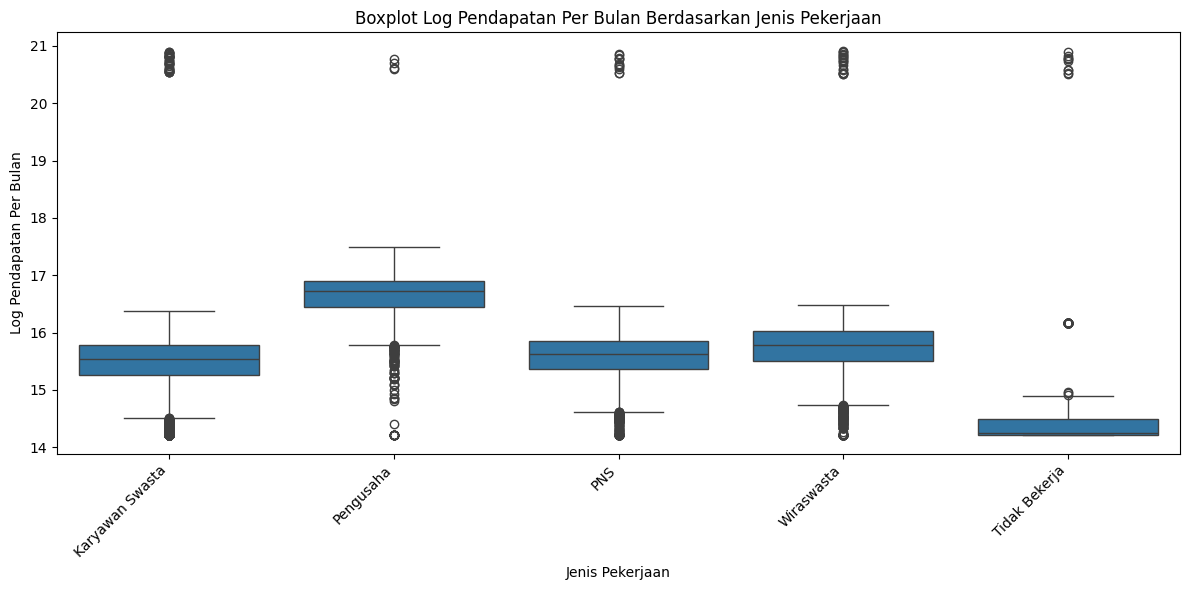

In [44]:
#buat boxplot pendapatan per bulan berdasarkan jenis pekerjaan setelah transformasi log
plt.figure(figsize=(12, 6))
sns.boxplot(x="jenis_pekerjaan", y="log_pendapatan_per_b", data=df)
plt.title("Boxplot Log Pendapatan Per Bulan Berdasarkan Jenis Pekerjaan")
plt.xlabel("Jenis Pekerjaan")
plt.ylabel("Log Pendapatan Per Bulan")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [45]:
#lihat skewness log pendapatan per bulan berdasarkan jenis pekerjaan
skewness_by_job = df.groupby("jenis_pekerjaan")["log_pendapatan_per_b"].skew().reset_index(name="skewness")
print(skewness_by_job)

   jenis_pekerjaan  skewness
0  Karyawan Swasta  3.490678
1              PNS  2.989092
2        Pengusaha -0.339112
3    Tidak Bekerja  5.908453
4       Wiraswasta  3.006178


In [48]:
#cek data ekstrem per pekerjaan
pd.crosstab(
    df["jenis_pekerjaan"],
    df["log_pendapatan_per_b"],
    margins=True
)
df[df["log_pendapatan_per_b"]] .groupby(
    "jenis_pekerjaan"
)["log_pendapatan_per_b"].agg(
    jumlah="count",
    minimum="min",
    median="median",
    maksimum="max"
)

KeyError: "None of [Index([ 15.63897749028175,  16.83551935755663, 15.385169889665907,\n       15.499967627297162, 15.312317141881593,  16.82795888652184,\n       15.105274470054098,  15.61652192938249, 15.761437278310854,\n       15.979620170735766,\n       ...\n       15.635774228230014, 16.230890354436685, 15.886101044366091,\n       15.297698337862476,  16.01408821946909, 14.220976332738882,\n        15.74336016426972, 15.591328297031446, 15.420141937504287,\n       14.220976332738882],\n      dtype='float64', length=20000)] are in the [columns]"

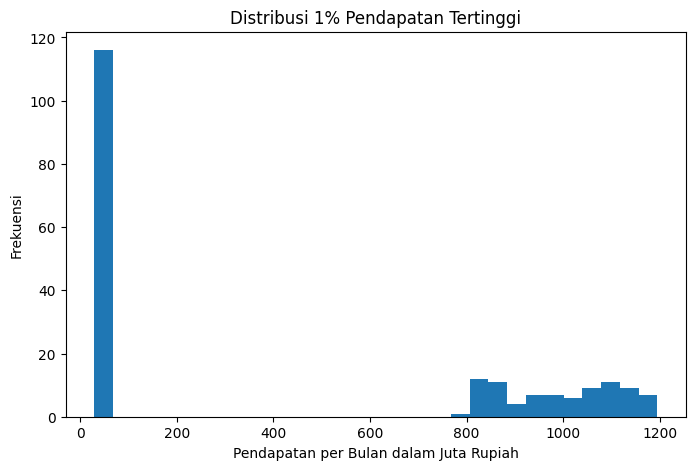

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(
    data_ekstrem["pendapatan_per_b"] / 1_000_000,
    bins=30
)
plt.xlabel("Pendapatan per Bulan dalam Juta Rupiah")
plt.ylabel("Frekuensi")
plt.title("Distribusi 1% Pendapatan Tertinggi")
plt.show()